# Swiggy Sales Analysis

### Import libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#### Importing database swiggy from Mysql

In [13]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="@Creativity_create_99",
    database="swiggy"
)

print("Connected successfully!")

Connected successfully!


In [14]:
query = "SHOW TABLES"
tables = pd.read_sql(query, conn)

tables

C:\Users\HP\AppData\Local\Temp\ipykernel_19944\234359449.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query, conn)


,Tables_in_swiggy
0,dim_category
1,dim_date
2,dim_dish
3,dim_location
4,dim_restaurant
5,swiggy_orders
6,swiggy_sales


In [15]:
df_sales = pd.read_sql("SELECT * FROM swiggy_sales", conn)

df_orders = pd.read_sql("SELECT * FROM swiggy_orders", conn)

df_date = pd.read_sql("SELECT * FROM dim_date", conn)

df_location = pd.read_sql("SELECT * FROM dim_location", conn)

df_restaurant = pd.read_sql("SELECT * FROM dim_restaurant", conn)

df_category = pd.read_sql("SELECT * FROM dim_category", conn)

df_dish = pd.read_sql("SELECT * FROM dim_dish", conn)

C:\Users\HP\AppData\Local\Temp\ipykernel_19944\525329351.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales = pd.read_sql("SELECT * FROM swiggy_sales", conn)
C:\Users\HP\AppData\Local\Temp\ipykernel_19944\525329351.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders = pd.read_sql("SELECT * FROM swiggy_orders", conn)
C:\Users\HP\AppData\Local\Temp\ipykernel_19944\525329351.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_date = pd.read_sql("SELECT * FROM dim_date", conn)
C:\Users\HP\AppData\Local\Te

In [16]:
print("SWIGGY SALES")
print(df_sales.head())

print("\nSWIGGY ORDERS")
print(df_orders.head())

print("\nDIM DATE")
print(df_date.head())

print("\nDIM LOCATION")
print(df_location.head())

print("\nDIM RESTAURANT")
print(df_restaurant.head())

print("\nDIM CATEGORY")
print(df_category.head())

print("\nDIM DISH")
print(df_dish.head())

SWIGGY SALES
       state       city  order_date           restaurant_name  \
0  Karnataka  Bengaluru  2025-06-29  Anand Sweets & Savouries   
1  Karnataka  Bengaluru  2025-04-03     Srinidhi Sagar Deluxe   
2  Karnataka  Bengaluru  2025-01-15     Srinidhi Sagar Deluxe   
3  Karnataka  Bengaluru  2025-04-17     Srinidhi Sagar Deluxe   
4  Karnataka  Bengaluru  2025-03-13     Srinidhi Sagar Deluxe   

               location     category             dish_name  price  rating  \
0  Rajarajeshwari Nagar        Snack  Butter Murukku-200gm  133.9     4.0   
1               Kengeri  Recommended            Badam Milk   52.0     4.5   
2               Kengeri  Recommended        Chow Chow Bath  117.0     4.7   
3               Kengeri  Recommended           Kesari Bath   65.0     4.6   
4               Kengeri  Recommended            Mix Raitha  130.0     4.0   

   rating_count  
0             0  
1            25  
2            48  
3            65  
4             0  

SWIGGY ORDERS
   order_i

In [17]:
print("swiggy_sales:", df_sales.shape)
print("swiggy_orders:", df_orders.shape)
print("dim_date:", df_date.shape)
print("dim_location:", df_location.shape)
print("dim_restaurant:", df_restaurant.shape)
print("dim_category:", df_category.shape)
print("dim_dish:", df_dish.shape)

swiggy_sales: (197403, 10)
swiggy_orders: (197403, 9)
dim_date: (243, 8)
dim_location: (964, 4)
dim_restaurant: (984, 2)
dim_category: (4774, 2)
dim_dish: (56588, 2)


In [18]:
query = """
SELECT
    so.order_id,
    d.full_date,
    d.year_num,
    d.month_name,
    d.month_num,
    dl.state,
    dl.city,
    dl.location,
    dr.restaurant_name,
    dc.category,
    di.dish_name,
    so.price,
    so.rating,
    so.rating_count
FROM swiggy_orders so
JOIN dim_date d
    ON so.date_id = d.date_id
JOIN dim_location dl
    ON so.location_id = dl.location_id
JOIN dim_restaurant dr
    ON so.restaurant_id = dr.restaurant_id
JOIN dim_category dc
    ON so.category_id = dc.category_id
JOIN dim_dish di
    ON so.dish_id = di.dish_id
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_19944\600912413.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,full_date,year_num,month_name,month_num,state,city,location,restaurant_name,category,dish_name,price,rating,rating_count
0,194,2025-06-29,2025,June,6,Karnataka,Bengaluru,Rajarajeshwari Nagar,Anand Sweets & Savouries,Snack,Butter Murukku-200gm,133.9,4.0,0
1,863,2025-04-03,2025,April,4,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Recommended,Badam Milk,52.0,4.5,25
2,1752,2025-01-15,2025,January,1,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Tandoori Breads,Butter Parrota,91.0,4.0,0
3,1759,2025-01-15,2025,January,1,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Ice Creams In Cup,Black Current,98.0,4.0,0
4,1801,2025-01-15,2025,January,1,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Fresh Fruit Juice,Cock-Tail,111.0,4.0,0


## Metadata

In [19]:
df.head()

,order_id,full_date,year_num,month_name,month_num,state,city,location,restaurant_name,category,dish_name,price,rating,rating_count
0,194,2025-06-29,2025,June,6,Karnataka,Bengaluru,Rajarajeshwari Nagar,Anand Sweets & Savouries,Snack,Butter Murukku-200gm,133.9,4.0,0
1,863,2025-04-03,2025,April,4,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Recommended,Badam Milk,52.0,4.5,25
2,1752,2025-01-15,2025,January,1,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Tandoori Breads,Butter Parrota,91.0,4.0,0
3,1759,2025-01-15,2025,January,1,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Ice Creams In Cup,Black Current,98.0,4.0,0
4,1801,2025-01-15,2025,January,1,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,Fresh Fruit Juice,Cock-Tail,111.0,4.0,0


In [20]:
df.tail()

,order_id,full_date,year_num,month_name,month_num,state,city,location,restaurant_name,category,dish_name,price,rating,rating_count
197398,193614,2025-03-07,2025,March,3,Sikkim,Gangtok,Gangtok,Mama's Kitchen,Roll,Corn cheese roll ...,112.0,5.0,3
197399,195183,2025-03-02,2025,March,3,Sikkim,Gangtok,Gangtok,Mama's Kitchen,Roll,Veg Chow Roll,100.0,5.0,3
197400,195966,2025-03-27,2025,March,3,Sikkim,Gangtok,Gangtok,Mama's Kitchen,Momos,Soya Momo,100.0,4.4,0
197401,196037,2025-03-27,2025,March,3,Sikkim,Gangtok,Gangtok,Mama's Kitchen,Roll,Cheese capsicum roll,130.0,4.4,0
197402,196704,2025-03-08,2025,March,3,Sikkim,Gangtok,Gangtok,Mama's Kitchen,Starters,Ting momo with aludum [2 pieces] ...,70.0,3.7,22


In [24]:
df["full_date"] = pd.to_datetime(df["full_date"])

In [25]:
df.shape

(197403, 14)

In [26]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 197403
Columns: 14


In [27]:
df.columns

Index(['order_id', 'full_date', 'year_num', 'month_name', 'month_num', 'state',
       'city', 'location', 'restaurant_name', 'category', 'dish_name', 'price',
       'rating', 'rating_count'],
      dtype='object')

In [28]:
df.dtypes

order_id                    int64
full_date          datetime64[ns]
year_num                    int64
month_name                 object
month_num                   int64
state                      object
city                       object
location                   object
restaurant_name            object
category                   object
dish_name                  object
price                     float64
rating                    float64
rating_count                int64
dtype: object

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197403 entries, 0 to 197402
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_id         197403 non-null  int64         
 1   full_date        197403 non-null  datetime64[ns]
 2   year_num         197403 non-null  int64         
 3   month_name       197403 non-null  object        
 4   month_num        197403 non-null  int64         
 5   state            197403 non-null  object        
 6   city             197403 non-null  object        
 7   location         197403 non-null  object        
 8   restaurant_name  197403 non-null  object        
 9   category         197403 non-null  object        
 10  dish_name        197403 non-null  object        
 11  price            197403 non-null  float64       
 12  rating           197403 non-null  float64       
 13  rating_count     197403 non-null  int64         
dtypes: datetime64[ns](1)

In [30]:
df.describe()

,order_id,full_date,year_num,month_num,price,rating,rating_count
count,197403.000000,197403,197403.0,197403.000000,197403.000000,197403.000000,197403.000000
mean,98702.000000,2025-05-01 19:42:28.028145152,2025.0,4.519278,268.501413,4.341579,28.323637
min,1.000000,2025-01-01 00:00:00,2025.0,1.000000,0.950000,1.500000,0.000000
25%,49351.500000,2025-03-01 00:00:00,2025.0,3.000000,139.000000,4.300000,0.000000
50%,98702.000000,2025-05-02 00:00:00,2025.0,5.000000,229.000000,4.400000,2.000000
75%,148052.500000,2025-07-01 00:00:00,2025.0,7.000000,329.000000,4.500000,15.000000
max,197403.000000,2025-08-31 00:00:00,2025.0,8.000000,8000.000000,5.000000,999.000000
std,56985.481932,NaN,0.0,2.299333,219.222980,0.422585,87.547541


In [31]:
df.describe(include='all')

,order_id,full_date,year_num,month_name,month_num,state,city,location,restaurant_name,category,dish_name,price,rating,rating_count
count,197403.000000,197403,197403.0,197403,197403.000000,197403,197403,197403,197403,197403,197403,197403.000000,197403.000000,197403.000000
unique,NaN,NaN,NaN,8,NaN,28,28,946,984,4774,56588,NaN,NaN,NaN
top,NaN,NaN,NaN,January,NaN,Karnataka,Bengaluru,Yelahanka,McDonald's,Recommended,Choco Lava Cake,NaN,NaN,NaN
freq,NaN,NaN,NaN,25393,NaN,20072,20072,2283,13528,24098,303,NaN,NaN,NaN
mean,98702.000000,2025-05-01 19:42:28.028145152,2025.0,NaN,4.519278,NaN,NaN,NaN,NaN,NaN,NaN,268.501413,4.341579,28.323637
min,1.000000,2025-01-01 00:00:00,2025.0,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.950000,1.500000,0.000000
25%,49351.500000,2025-03-01 00:00:00,2025.0,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,139.000000,4.300000,0.000000
50%,98702.000000,2025-05-02 00:00:00,2025.0,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,229.000000,4.400000,2.000000
75%,148052.500000,2025-07-01 00:00:00,2025.0,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,329.000000,4.500000,15.000000
max,197403.000000,2025-08-31 00:00:00,2025.0,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,8000.000000,5.000000,999.000000


In [32]:
df.isnull().sum()

order_id           0
full_date          0
year_num           0
month_name         0
month_num          0
state              0
city               0
location           0
restaurant_name    0
category           0
dish_name          0
price              0
rating             0
rating_count       0
dtype: int64

In [33]:
(df.isnull().sum()/len(df))*100

order_id           0.0
full_date          0.0
year_num           0.0
month_name         0.0
month_num          0.0
state              0.0
city               0.0
location           0.0
restaurant_name    0.0
category           0.0
dish_name          0.0
price              0.0
rating             0.0
rating_count       0.0
dtype: float64

In [35]:
df.nunique()

order_id           197403
full_date             243
year_num                1
month_name              8
month_num               8
state                  28
city                   28
location              946
restaurant_name       984
category             4774
dish_name           56588
price                2755
rating                 36
rating_count          963
dtype: int64

## KPIs

##### Total Orders

In [36]:
print("Total Orders:", len(df))

Total Orders: 197403


##### Total Revenue

In [37]:
total_revenue_million = df["price"].sum() / 1_000_000

print(f"Total Revenue: {total_revenue_million:.2f} Million")

Total Revenue: 53.00 Million


##### Average Order Value

In [38]:
print("Average Order Value:", round(df["price"].mean(), 2))

Average Order Value: 268.5


##### Highest Order Value

In [39]:
print("Highest Order Value:", df["price"].max())

Highest Order Value: 8000.0


##### Average Rating

In [40]:
print("Average Rating:", round(df["rating"].mean(), 2))

Average Rating: 4.34


##### Total Restaurants

In [41]:
print("Total Restaurants:", df["restaurant_name"].nunique())

Total Restaurants: 984


##### Total Cities

In [42]:
print("Total Cities:", df["city"].nunique())

Total Cities: 28


##### Total Categories

In [43]:
print("Total Categories:", df["category"].nunique())

Total Categories: 4774


##### Total Dishes

In [44]:
print("Total Dishes:", df["dish_name"].nunique())

Total Dishes: 56588


# Chart Design

### Monthly Sales Trend

In [45]:
monthly_sales = (
    df.groupby(["month_num", "month_name"])["price"]
      .sum()
      .reset_index()
      .sort_values("month_num")
)

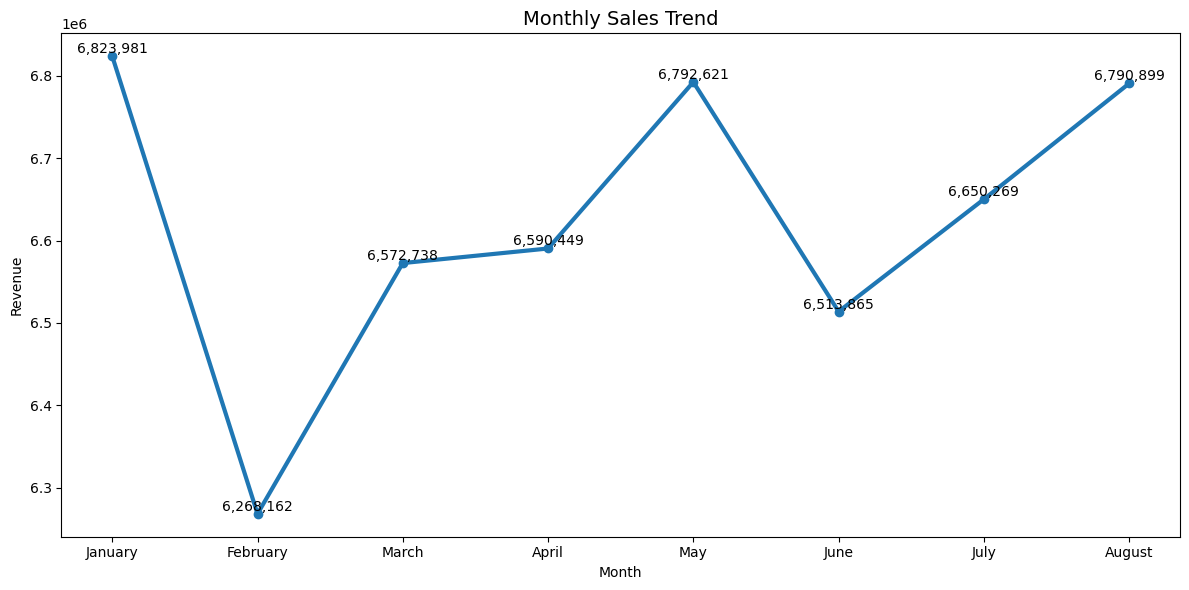

In [46]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["month_name"],
    monthly_sales["price"],
    marker="o",
    linewidth=3
)

for x, y in zip(monthly_sales["month_name"], monthly_sales["price"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue")


plt.tight_layout()
plt.show()

### Weekly Sales Trend

In [47]:
df["day_name"] = df["full_date"].dt.day_name()

In [48]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_sales = (
    df.groupby("day_name")["price"]
      .sum()
      .reindex(day_order)
      .reset_index()
)

weekly_sales["sales_million"] = weekly_sales["price"] / 1000000

weekly_sales

,day_name,price,sales_million
0,Monday,7444475.14,7.444475
1,Tuesday,7358996.01,7.358996
2,Wednesday,7541692.52,7.541693
3,Thursday,7663248.59,7.663249
4,Friday,7579482.84,7.579483
5,Saturday,7778260.40,7.778260
6,Sunday,7636828.97,7.636829


In [49]:
fig = px.bar(
    weekly_sales,
    x="day_name",
    y="sales_million",
    text="sales_million",
    title="Weekly Sales Trend Analysis"
)

fig.update_traces(
    marker_color="yellow",
    texttemplate="%{text:.2f}M",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Day of Week",
    yaxis_title="Sales (Millions)",
    showlegend=False
)

fig.show()

### Total Sales by State

In [50]:
state_sales = (
    df.groupby("state")["price"]
      .sum()
      .reset_index()
      .sort_values("price", ascending=True)
)

state_sales["sales_million"] = state_sales["price"] / 1000000

In [51]:
fig = px.bar(
    state_sales,
    x="sales_million",
    y="state",
    orientation="h",
    text="sales_million",
    title="Total Sales by State (Millions)"
)

fig.update_traces(
    texttemplate='%{text:.2f}M',
    textposition='outside'
)

fig.update_layout(
    xaxis_title="Sales (Millions)",
    yaxis_title="State",
    showlegend=False,
    height=700
)

fig.show()

### Quarterly Performance

In [52]:
df["full_date"] = pd.to_datetime(df["full_date"])

df["quarter"] = "Q" + df["full_date"].dt.quarter.astype(str)

In [53]:
quarterly_summary = (
    df.groupby("quarter")
      .agg(
          Total_Sales=("price", "sum"),
          Total_Orders=("order_id", "count"),
          Avg_Order_Value=("price", "mean"),
          Avg_Rating=("rating", "mean")
      )
      .reset_index()
)

quarterly_summary["Total_Sales_M"] = (
    quarterly_summary["Total_Sales"] / 1000000
).round(2)

quarterly_summary["Avg_Order_Value"] = (
    quarterly_summary["Avg_Order_Value"]
).round(2)

quarterly_summary["Avg_Rating"] = (
    quarterly_summary["Avg_Rating"]
).round(2)

quarterly_summary = quarterly_summary[
    [
        "quarter",
        "Total_Sales_M",
        "Total_Orders",
        "Avg_Order_Value",
        "Avg_Rating"
    ]
]

quarterly_summary

,quarter,Total_Sales_M,Total_Orders,Avg_Order_Value,Avg_Rating
0,Q1,19.66,73085,269.07,4.34
1,Q2,19.90,74155,268.32,4.34
2,Q3,13.44,50163,267.95,4.34


In [54]:
quarterly_summary = quarterly_summary.sort_values("quarter")

In [55]:
quarterly_summary.style.background_gradient(
    subset=["Total_Sales_M"],
    cmap="YlGn"
)

,quarter,Total_Sales_M,Total_Orders,Avg_Order_Value,Avg_Rating
0,Q1,19.660000,73085,269.070000,4.340000
1,Q2,19.900000,74155,268.320000,4.340000
2,Q3,13.440000,50163,267.950000,4.340000


### Top 10 Cities by Sales

In [56]:
city_sales = (
    df.groupby("city")["price"]
      .sum()
      .reset_index()
      .sort_values("price", ascending=False)
      .head(10)
)

city_sales["sales_million"] = city_sales["price"] / 1000000

city_sales

,city,price,sales_million
3,Bengaluru,5455887.73,5.455888
18,Lucknow,3117359.65,3.117360
11,Hyderabad,3021711.62,3.021712
19,Mumbai,3015573.35,3.015573
20,New Delhi,2829180.60,2.829181
1,Ahmedabad,2815536.27,2.815536
5,Chandigarh,2804991.82,2.804992
17,Kolkata,2662213.76,2.662214
6,Chennai,2642594.63,2.642595
14,Jaipur,2502833.61,2.502834


In [57]:
fig = px.bar(
    city_sales.sort_values("sales_million"),
    x="sales_million",
    y="city",
    orientation="h",
    text="sales_million",
    title="Top 10 Cities by Sales"
)

fig.update_traces(
    texttemplate="%{text:.2f}M",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Sales (Millions)",
    yaxis_title="City",
    showlegend=False,
    height=600
)

fig.show()

### Total Sales by Food Type (Veg VS Non-Veg)

In [58]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biryani", "kebab",
    "kabab", "non-veg", "non veg"
]

df["food_category"] = np.where(
    df["dish_name"].str.lower().str.contains(
        "|".join(non_veg_keywords),
        na=False
    ),
    "Non-Veg",
    "Veg"
)

In [59]:
food_revenue = (
    df.groupby("food_category")["price"]
      .sum()
      .reset_index()
)

food_revenue

,food_category,price
0,Non-Veg,19681119.01
1,Veg,33321865.46


In [60]:
fig = px.pie(
    food_revenue,
    names="food_category",
    values="price",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg"
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.08, 0.08]   # creates the broken/exploded effect
)

fig.show()